# Understanding the Data

This notebook explores two key questions about a grocery e-commerce dataset:

**H1 – One-time buyers:** *The majority of our users only place a single order, which may indicate a retention problem.*  
Approach: Classify customers as one-time vs. repeat buyers, analyse order-frequency distribution, and compare basket size/value between both groups.

**H2 – Pareto distribution in product categories:** *A small subset of product categories (~20%) accounts for the majority (~80%) of total sales.*  
Approach: Compute total sales per category, rank them, and plot a cumulative Pareto curve.

A second part of the notebook performs an **Exploratory Data Analysis (EDA)** of the `feature_frame` dataset, which is designed to train a model that pre-populates a user's next shopping basket.

In [14]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

plt.style.use('ggplot')
pd.set_option('display.float_format', '{:.4f}'.format)

# ---------------------------------------------------------------------------
# Paths: use an environment variable so any collaborator can override the root
# Export DATA_ROOT before running, e.g.:
#   export DATA_ROOT=/path/to/project
# Falls back to two levels above this notebook if the variable is not set.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(os.environ.get('DATA_ROOT', Path().resolve().parents[1]))
data_path = PROJECT_ROOT / 'data' / 'raw'

print('Project root:', PROJECT_ROOT)
print('Data path:   ', data_path)

Project root: /home/tomas/zrive-ds
Data path:    /home/tomas/zrive-ds/data/raw


First we load the data:

In [19]:
orders    = pd.read_parquet(data_path / 'orders.parquet')
inventory = pd.read_parquet(data_path / 'inventory.parquet')

print('orders shape:   ', orders.shape)
print('inventory shape:', inventory.shape)

orders shape:    (8773, 6)
inventory shape: (1733, 6)


---
## 1. High-level Dataset Overview

Before diving into analysis it is good practice to understand what each dataset represents:

| Dataset | Grain | Key fields |
|---------|-------|------------|
| `orders` | One row per order | `id`, `user_id`, `created_at`, `order_date`, `user_order_seq`, `ordered_items` (list of variant IDs) |
| `inventory` | One row per product variant | `variant_id`, `price`, `compare_at_price`, `vendor`, `product_type`, `tags` |

The `ordered_items` column is a list, so each order can contain multiple products. We will explode this column later to obtain a flat *order-items* table that can be joined with inventory.

---
## 2. Quick Data-Quality Checks

We run basic sanity checks on both raw datasets **before** any transformation. The goal is to catch issues early: missing values, duplicated records, unexpected data types, and obvious numerical outliers.

### 2.1 Orders

In [21]:
print('--- Orders ---')
print('Shape:', orders.shape)
print('\nDtypes:')
print(orders.dtypes)
print('\nMissing values:')
print(orders.isnull().sum())

# Exclude the list column from the full-row duplicate check
# (lists are not hashable and would raise an error)
cols_to_check = [c for c in orders.columns if c != 'ordered_items']
print('\nDuplicate rows (excl. ordered_items):', orders.duplicated(subset=cols_to_check).sum())
print('Duplicate order IDs:                 ', orders['id'].duplicated().sum())

orders.head()

--- Orders ---
Shape: (8773, 6)

Dtypes:
id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object
dtype: object

Missing values:
id                0
user_id           0
created_at        0
order_date        0
user_order_seq    0
ordered_items     0
dtype: int64

Duplicate rows (excl. ordered_items): 0
Duplicate order IDs:                  0


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


**Results – Orders:**
- No missing values and no duplicate rows or order IDs — the dataset is clean at the identifier level.
- `ordered_items` is stored as a Python list inside each cell; we will explode it in the next section.
- `user_order_seq` tracks the sequential order number per user, which we will use to identify one-time buyers.

Items per order:
count   8773.0000
mean      12.3057
std        6.8395
min        1.0000
25%        8.0000
50%       11.0000
75%       15.0000
max      114.0000
Name: n_items, dtype: float64


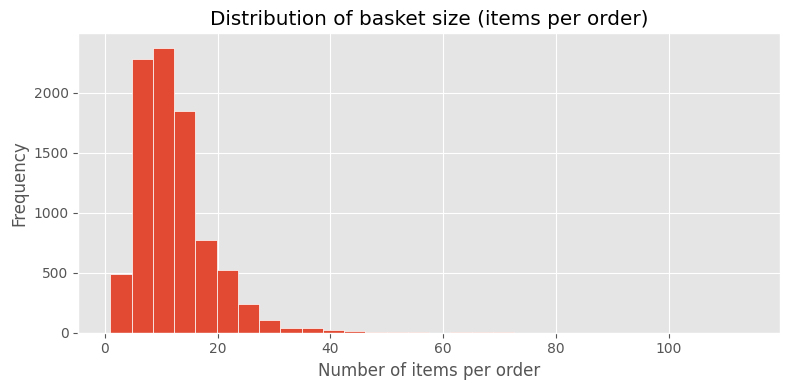

In [22]:
# Distribution of items per order
# This helps us understand whether orders are typically small or large baskets
# and flag any suspicious extremes (e.g. orders with 0 or hundreds of items).
orders['n_items'] = orders['ordered_items'].apply(len)

print('Items per order:')
print(orders['n_items'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
orders['n_items'].plot(kind='hist', bins=30, ax=ax, color='C0', edgecolor='white')
ax.set_xlabel('Number of items per order')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of basket size (items per order)')
plt.tight_layout()
plt.show()

**Results – Basket size:**
- The median order contains **11 items** and the mean is ~12, which is consistent with a weekly grocery shop.
- The distribution is right-skewed; a small number of orders contain more than 40 items, with one outlier reaching 114. These could be bulk purchases or data entry errors and may warrant further investigation.

### 2.2 Inventory

In [23]:
print('--- Inventory ---')
print('Shape:', inventory.shape)
print('\nDtypes:')
print(inventory.dtypes)
print('\nMissing values:')
print(inventory.isnull().sum())

cols_to_check = [c for c in inventory.columns if c != 'tags']
print('\nDuplicate rows (excl. tags):', inventory.duplicated(subset=cols_to_check).sum())
print('Negative prices:            ', (inventory['price'] < 0).sum())

inventory.describe()

--- Inventory ---
Shape: (1733, 6)

Dtypes:
variant_id            int64
price               float64
compare_at_price    float64
vendor               object
product_type         object
tags                 object
dtype: object

Missing values:
variant_id          0
price               0
compare_at_price    0
vendor              0
product_type        0
tags                0
dtype: int64

Duplicate rows (excl. tags): 0
Negative prices:             0


,variant_id,price,compare_at_price
count,1733.0000,1733.0000,1733.0000
mean,36948799362316.4922,6.3074,7.0289
std,2725674300769.7231,7.1072,7.6605
min,33615294398596.0000,0.0000,0.0000
25%,34276571054212.0000,2.4900,2.8500
50%,39272600862852.0000,3.9900,4.4900
75%,39483175960708.0000,7.4900,8.2100
max,40167931707524.0000,59.9900,60.0000


**Results – Inventory:**
- No missing values, no duplicates, no negative prices — the dataset is clean.
- Prices range from £0 to ~£60 with a median of ~£4, consistent with everyday grocery items.
- `compare_at_price` is systematically higher than `price`, confirming it represents a reference/RRP price used to compute the discount.

---
## 3. Building the Order-Items Table

The `orders` dataset stores the list of purchased variant IDs in a single cell (`ordered_items`). To enable product-level analysis we:
1. **Explode** `ordered_items` so each row represents one (order, product) pair.
2. **Join** with `inventory` on `variant_id` to enrich each row with price and category information.

After the join we check for unmatched items, which could indicate discontinued products or inventory snapshots that don't cover the full order history.

In [25]:
order_items = (
    orders
    .explode('ordered_items')
    .rename(columns={'ordered_items': 'variant_id'})
    .merge(inventory, on='variant_id', how='left')
)

print('order_items shape:', order_items.shape)
order_items.info()

missing_inventory = order_items['product_type'].isna().sum()
print(f'\nItems not matched to inventory: {missing_inventory} ({missing_inventory / len(order_items):.1%})')

order_items shape: (107958, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107958 entries, 0 to 107957
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                107958 non-null  int64         
 1   user_id           107958 non-null  object        
 2   created_at        107958 non-null  datetime64[us]
 3   order_date        107958 non-null  datetime64[us]
 4   user_order_seq    107958 non-null  int64         
 5   variant_id        107958 non-null  object        
 6   n_items           107958 non-null  int64         
 7   price             92361 non-null   float64       
 8   compare_at_price  92361 non-null   float64       
 9   vendor            92361 non-null   object        
 10  product_type      92361 non-null   object        
 11  tags              92361 non-null   object        
dtypes: datetime64[us](2), float64(2), int64(3), object(5)
memory usage: 9.9+ MB

Items

**Result:** 14.4% of order-item rows could not be matched to the inventory table.  
This likely means those products are no longer active in the current catalogue snapshot, rather than an error in the orders data. This should be flagged to the client for clarification.

---
## 4. H1 – One-time Buyers

**Hypothesis:** The majority of our users only place a single order, which may indicate a retention problem.  
**Approach:**
- Count orders per user and classify them as one-time vs. repeat buyers.
- Cross-validate using `user_order_seq`.
- Compare **basket size** (number of items) and **basket value** (total spend) between both groups to understand behavioural differences.

In [26]:
# Count distinct orders per user
orders_per_user = (
    orders.groupby('user_id')['id']
    .nunique()
    .reset_index()
    .rename(columns={'id': 'n_orders'})
)

one_time_buyers = orders_per_user[orders_per_user['n_orders'] == 1]
repeat_buyers   = orders_per_user[orders_per_user['n_orders'] >  1]
total_users     = len(orders_per_user)

print(f'Total users:    {total_users}')
print(f'One-time buyers: {len(one_time_buyers)} ({len(one_time_buyers)/total_users:.1%})')
print(f'Repeat buyers:   {len(repeat_buyers)}  ({len(repeat_buyers)/total_users:.1%})')

# Cross-check via user_order_seq
max_seq = orders.groupby('user_id')['user_order_seq'].max()
print(f'\nOne-time buyers (via user_order_seq): {(max_seq == 1).sum()} ({(max_seq == 1).mean():.1%})')

Total users:    4983
One-time buyers: 3572 (71.7%)
Repeat buyers:   1411  (28.3%)

One-time buyers (via user_order_seq): 3572 (71.7%)


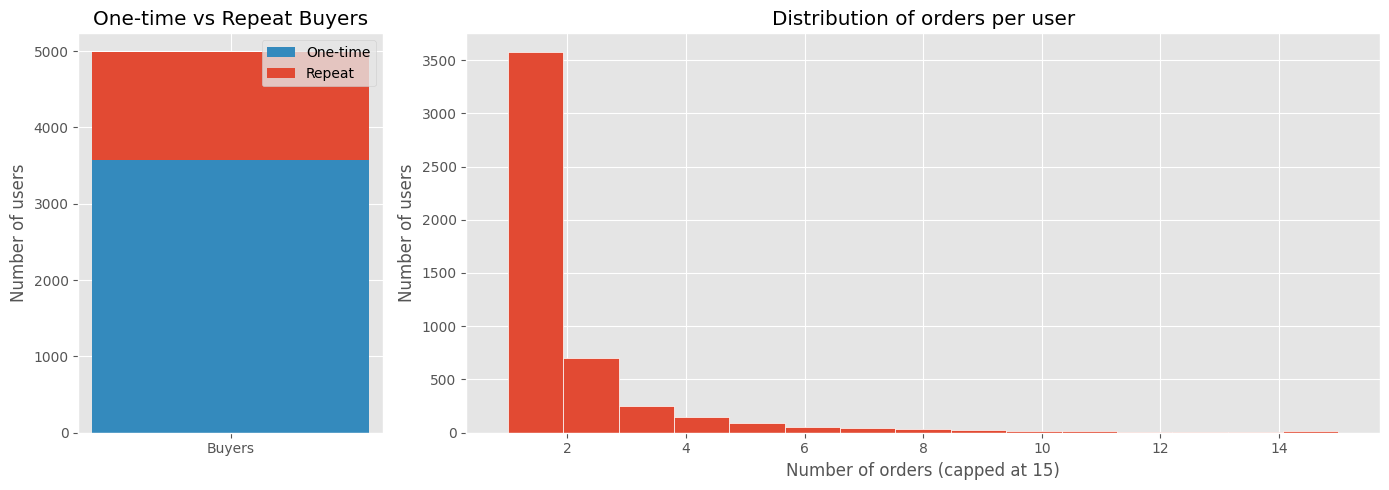

Repeat buyers — order statistics:
count   1411.0000
mean       3.6860
std        2.8417
min        2.0000
25%        2.0000
50%        3.0000
75%        4.0000
max       25.0000
Name: n_orders, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 3]})

# Stacked bar
axes[0].bar(['Buyers'], [len(one_time_buyers)], label='One-time', color='C1', width=0.4)
axes[0].bar(['Buyers'], [len(repeat_buyers)], bottom=[len(one_time_buyers)], label='Repeat', color='C0', width=0.4)
axes[0].set_title('One-time vs Repeat Buyers')
axes[0].set_ylabel('Number of users')
axes[0].legend()

# Order-frequency histogram (capped for readability)
orders_per_user['n_orders'].clip(upper=15).hist(bins=15, ax=axes[1], color='C0', edgecolor='white')
axes[1].set_xlabel('Number of orders (capped at 15)')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Distribution of orders per user')

plt.tight_layout()
plt.show()

print('Repeat buyers — order statistics:')
print(repeat_buyers['n_orders'].describe())

### 4.1 Basket size and value comparison

A useful complementary view is to compare whether one-time and repeat buyers behave differently in terms of how much they buy. This can help distinguish between users who were genuinely dissatisfied versus those who simply had a single purchase need.

In [28]:
# Tag each order with buyer type
orders_tagged = orders.merge(
    orders_per_user[['user_id', 'n_orders']], on='user_id'
)
orders_tagged['buyer_type'] = orders_tagged['n_orders'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)

# Basket value: sum of item prices per order
order_value = (
    order_items.dropna(subset=['price'])
    .groupby('id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'basket_value'})
)
orders_tagged = orders_tagged.merge(order_value, on='id', how='left')

# Summary statistics by buyer type
summary = orders_tagged.groupby('buyer_type').agg(
    n_orders_total=('id', 'count'),
    avg_basket_size=('n_items', 'mean'),
    median_basket_size=('n_items', 'median'),
    avg_basket_value=('basket_value', 'mean'),
    median_basket_value=('basket_value', 'median'),
).round(2)
print(summary)

            n_orders_total  avg_basket_size  median_basket_size  \
buyer_type                                                        
One-time              3572          11.7000             11.0000   
Repeat                5201          12.7200             11.0000   

            avg_basket_value  median_basket_value  
buyer_type                                         
One-time             51.8100              51.2400  
Repeat               59.0800              52.9400  


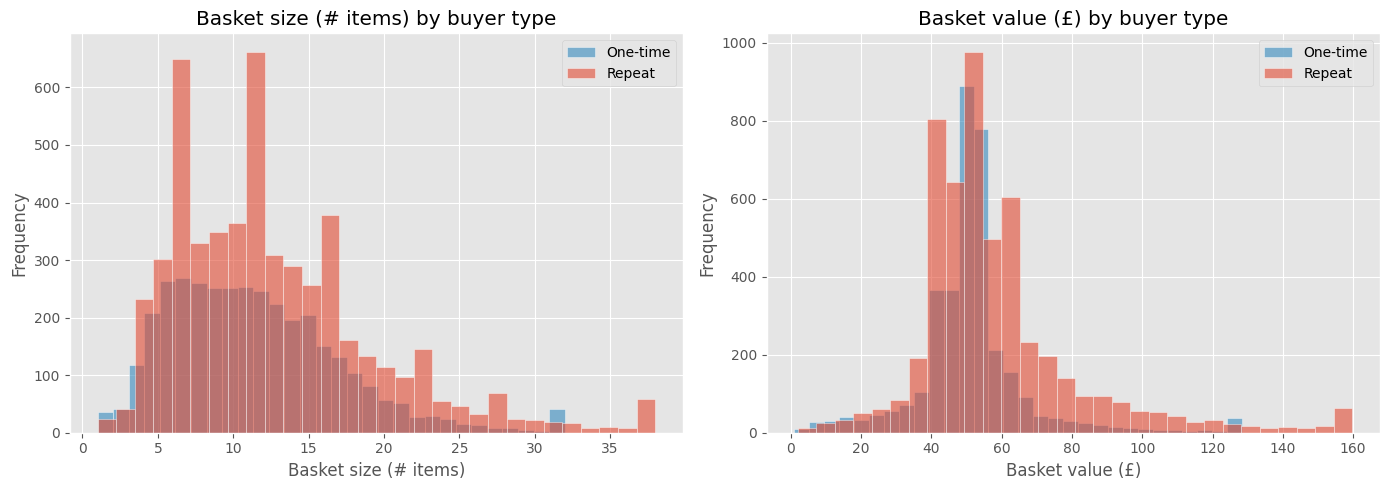

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(
    axes,
    ['n_items', 'basket_value'],
    ['Basket size (# items)', 'Basket value (£)']
):
    for buyer_type, color in [('One-time', 'C1'), ('Repeat', 'C0')]:
        subset = orders_tagged[orders_tagged['buyer_type'] == buyer_type][col].dropna()
        subset.clip(upper=subset.quantile(0.99)).hist(
            bins=30, ax=ax, alpha=0.6, color=color, label=buyer_type, edgecolor='white'
        )
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} by buyer type')
    ax.legend()

plt.tight_layout()
plt.show()

---

### H1 – Key Insights

- **71.7% of users placed only one order**, confirming the hypothesis. This is a significant retention challenge worth investigating.
- Possible explanations include dissatisfaction with the service, a single specific purchase need (e.g. a promotional offer), or insufficient re-engagement after the first order.
- Repeat buyers place on average **3.7 orders** (median 3). The fact that some users return many times shows the product has value for a loyal segment — but it is premature to conclude they are necessarily *more satisfied*; they may simply have different purchasing patterns or motivations.
- **Basket size and value are nearly identical between groups** — both have a median of 11 items per order, and median spend is very similar (£51.24 vs £52.94). One-time buyers do not appear to abandon after a small or unsatisfying shop.
- This means **the key differentiator is frequency, not per-visit behaviour**, which shifts the likely explanation away from in-order dissatisfaction and towards factors like insufficient re-engagement or a one-off trigger for the first purchase.
- **Implication:** Retention strategies should focus on the post-first-order window (e.g. follow-up campaigns, personalised recommendations) rather than improving the in-order experience, which already appears comparable between both groups.

---
## 5. H2 – Pareto Distribution in Product Categories

**Hypothesis:** A small subset of product categories accounts for the vast majority of total sales revenue.  
**Approach:** Rank categories by total sales, compute cumulative share, and compare against the classic 80/20 rule.

In [30]:
sales_by_category = (
    order_items
    .dropna(subset=['product_type'])
    .groupby('product_type')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'price': 'total_sales'})
)

sales_by_category['pct_sales']      = sales_by_category['total_sales'] / sales_by_category['total_sales'].sum()
sales_by_category['cumulative_pct'] = sales_by_category['pct_sales'].cumsum()

n_to_80    = (sales_by_category['cumulative_pct'] <= 0.8).sum() + 1
n_total    = len(sales_by_category)
pct_to_80  = n_to_80 / n_total

print(f'Total categories:                   {n_total}')
print(f'Categories needed to reach 80% revenue: {n_to_80} ({pct_to_80:.1%})')
print('\nTop 10 categories:')
sales_by_category.head(10)

Total categories:                   58
Categories needed to reach 80% revenue: 22 (37.9%)

Top 10 categories:


,product_type,total_sales,pct_sales,cumulative_pct
0,long-life-milk-substitutes,71736.7000,0.1465,0.1465
1,cleaning-products,31948.0400,0.0652,0.2117
2,toilet-roll-kitchen-roll-tissue,30270.6600,0.0618,0.2735
3,tins-packaged-foods,28662.8600,0.0585,0.3320
4,dishwashing,27163.9800,0.0555,0.3875
5,washing-powder,22321.7500,0.0456,0.4330
6,soft-drinks-mixers,22008.8200,0.0449,0.4780
7,washing-liquid-gel,16389.1800,0.0335,0.5114
8,snacks-confectionery,15958.6300,0.0326,0.5440
9,fabric-softener-freshener,12867.0700,0.0263,0.5703


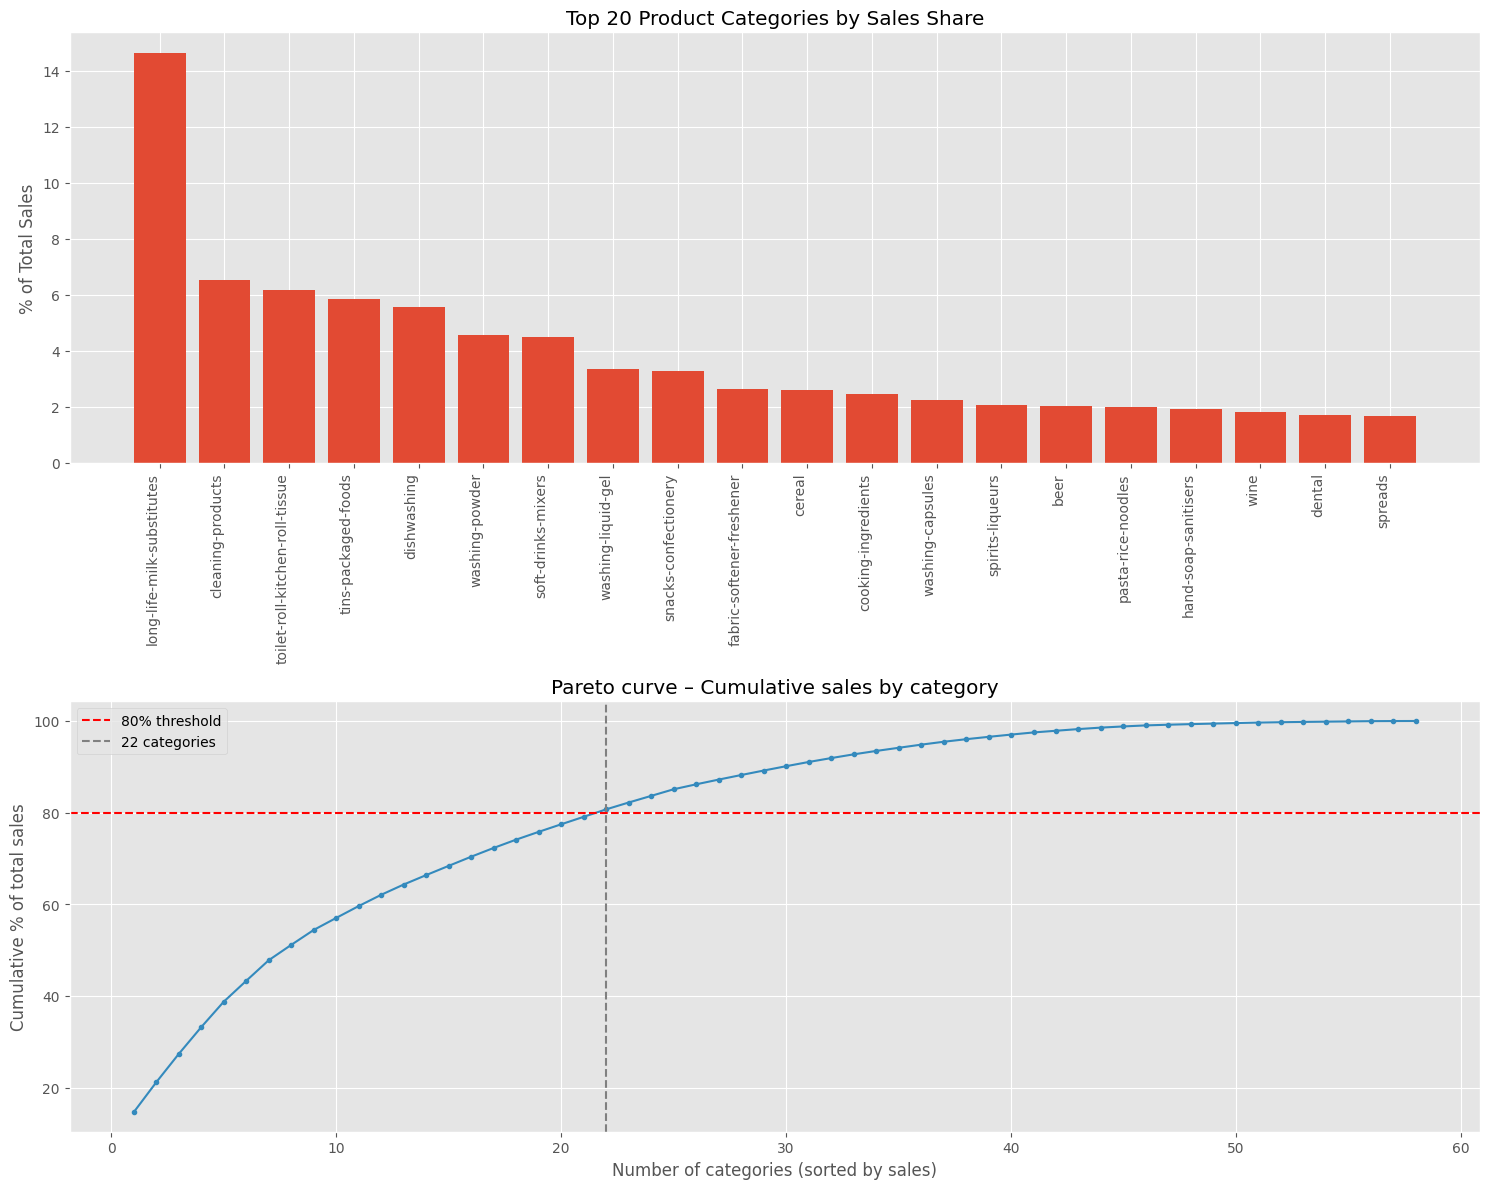

In [31]:
top_n = 20
top_cats = sales_by_category.head(top_n)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Bar chart — top 20
axes[0].bar(range(top_n), top_cats['pct_sales'] * 100, color='C0', tick_label=top_cats['product_type'])
axes[0].set_xticklabels(top_cats['product_type'], rotation=90, ha='right')
axes[0].set_ylabel('% of Total Sales')
axes[0].set_title(f'Top {top_n} Product Categories by Sales Share')

# Pareto curve
axes[1].plot(range(1, n_total + 1), sales_by_category['cumulative_pct'] * 100, color='C1', marker='.')
axes[1].axhline(y=80,       color='red',  linestyle='--', label='80% threshold')
axes[1].axvline(x=n_to_80,  color='gray', linestyle='--', label=f'{n_to_80} categories')
axes[1].set_xlabel('Number of categories (sorted by sales)')
axes[1].set_ylabel('Cumulative % of total sales')
axes[1].set_title('Pareto curve – Cumulative sales by category')
axes[1].legend()

plt.tight_layout()
plt.show()

### H2 – Key Insights

- **22 out of 58 categories (~38%) are sufficient to reach 80% of revenue** — the distribution follows an 80/40 rule rather than the classic 80/20, meaning concentration is real but less extreme than in many sectors.
- **Long-life milk substitutes** is by far the dominant category, alone accounting for ~14.6% of total sales. This is a star category worth deeper product analysis.
- Note that 14.4% of order-item rows could not be matched to inventory; the sales figures above exclude those rows and therefore slightly underestimate absolute totals. The relative ranking among categories is unlikely to be materially affected.

---
## 6. Exploratory Data Analysis — Feature Frame

The `feature_frame` dataset is specifically constructed to train a **next-basket recommendation model**. Key points to keep in mind when analysing it:

- It only contains the **most frequently purchased products** — long-tail products that almost no one buys are excluded.
- It only covers **repeat orders** (orders after the first one per user).
- The binary `outcome` column indicates whether that product was actually purchased in that order (1) or not (0).
- The model will use this data to predict which products to pre-populate in a user's basket before they visit.

In [32]:
feature_frame = pd.read_csv(data_path / 'feature_frame.csv')

# Fix date columns (stored as object)
feature_frame['created_at'] = pd.to_datetime(feature_frame['created_at'])
feature_frame['order_date'] = pd.to_datetime(feature_frame['order_date'])

print('Shape:', feature_frame.shape)
feature_frame.head()

Shape: (2880549, 27)


,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,33.0000,42.0000,31.1341,30.0000,30.0000,24.2762
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,33.0000,42.0000,31.1341,30.0000,30.0000,24.2762
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,33.0000,42.0000,31.1341,30.0000,30.0000,24.2762
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,33.0000,42.0000,31.1341,30.0000,30.0000,24.2762
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06,3,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,33.0000,42.0000,31.1341,30.0000,30.0000,24.2762


### 6.1 Data-quality checks

In [33]:
print('Missing values:')
print(feature_frame.isnull().sum())
print('\nDuplicate rows:', feature_frame.duplicated().sum())

Missing values:
variant_id                          0
product_type                        0
order_id                            0
user_id                             0
created_at                          0
order_date                          0
user_order_seq                      0
outcome                             0
ordered_before                      0
abandoned_before                    0
active_snoozed                      0
set_as_regular                      0
normalised_price                    0
discount_pct                        0
vendor                              0
global_popularity                   0
count_adults                        0
count_children                      0
count_babies                        0
count_pets                          0
people_ex_baby                      0
days_since_purchase_variant_id      0
avg_days_to_buy_variant_id          0
std_days_to_buy_variant_id          0
days_since_purchase_product_type    0
avg_days_to_buy_product_type      

**Result:** No missing values and no duplicate rows — the dataset is clean.

### 6.2 Target variable — class balance

In [34]:
outcome_dist = feature_frame['outcome'].value_counts(normalize=True)
print('Outcome distribution:')
print(outcome_dist)
print(f'\nClass imbalance ratio: {outcome_dist[0.0]/outcome_dist[1.0]:.0f}:1')

Outcome distribution:
outcome
0.0000   0.9885
1.0000   0.0115
Name: proportion, dtype: float64

Class imbalance ratio: 86:1


**Result:** The target is highly imbalanced — only ~1.15% of rows are positive (product was purchased). This is expected given that the feature frame includes many candidate products that were *not* bought. Any model trained on this data will need strategies to handle the imbalance (e.g. class weights, oversampling, or threshold tuning).

### 6.3 Binary features vs. outcome

We compare purchase rates for each binary feature and also run a **Chi-squared test** to assess whether the association is statistically significant, beyond what could be explained by the class imbalance alone.

In [35]:
binary_cols = ['ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular']

results = []
for col in binary_cols:
    purchase_rate = feature_frame.groupby(col)['outcome'].mean().mul(100).round(2)
    contingency   = pd.crosstab(feature_frame[col], feature_frame['outcome'])
    chi2, p, _, _ = chi2_contingency(contingency)
    results.append({
        'feature':          col,
        'rate_when_0 (%)':  purchase_rate.get(0.0, float('nan')),
        'rate_when_1 (%)':  purchase_rate.get(1.0, float('nan')),
        'chi2':             round(chi2, 2),
        'p_value':          f'{p:.2e}',
    })

binary_summary = pd.DataFrame(results).set_index('feature')
print(binary_summary)

                  rate_when_0 (%)  rate_when_1 (%)        chi2   p_value
feature                                                                 
ordered_before             0.8200          16.5000 128400.1400  0.00e+00
abandoned_before           1.1100          71.7900  76783.1300  0.00e+00
active_snoozed             1.1300          11.3500   6023.5600  0.00e+00
set_as_regular             1.0700          24.9700  52182.6500  0.00e+00


**Insights – Binary features:**

All four features show a **statistically significant** association with `outcome` (p-values are effectively zero across the board), and all follow the same pattern: any prior interaction with a product dramatically increases the probability of purchasing it.

| Feature | Rate (=0) | Rate (=1) | Interpretation |
|---------|-----------|-----------|----------------|
| `ordered_before` | 0.82% | 16.50% | Having purchased the product before yields a **~20× lift**. Purchase history is a strong signal. |
| `abandoned_before` | 1.11% | 71.79% | If a user previously added this product to their cart but didn't buy it, there is a **~72% chance they eventually purchase it**. By far the strongest single feature. |
| `active_snoozed` | 1.13% | 11.35% | Snoozed products have a **~10× higher purchase rate** than non-snoozed ones. |
| `set_as_regular` | 1.07% | 24.97% | Products marked as regular are purchased **~25% of the time** vs ~1% for non-regular items. |

The chi-squared statistics reinforce this ranking: `ordered_before` (128,400) and `set_as_regular` (52,183) are the most statistically dominant, while `active_snoozed` (6,024), though still highly significant, has a comparatively weaker association — likely because snoozed products are rare in the dataset. All four features are strong candidates for a predictive model.

### 6.4 Numerical features — descriptive statistics and distributions

In [36]:
num_cols = [
    'normalised_price', 'discount_pct', 'global_popularity',
    'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id'
]
print('Descriptive statistics:')
feature_frame[num_cols].describe()

Descriptive statistics:


,normalised_price,discount_pct,global_popularity,days_since_purchase_variant_id,avg_days_to_buy_variant_id
count,2880549.0000,2880549.0000,2880549.0000,2880549.0000,2880549.0000
mean,0.1273,0.1863,0.0107,33.1296,35.2373
std,0.1268,0.1934,0.0166,3.7072,10.5777
min,0.0160,-0.0402,0.0000,0.0000,0.0000
25%,0.0539,0.0846,0.0016,33.0000,30.0000
50%,0.0811,0.1169,0.0063,33.0000,34.0000
75%,0.1353,0.2235,0.0142,33.0000,40.0000
max,1.0000,1.3253,0.4254,148.0000,84.0000


**Initial observations before cleaning:**

- `normalised_price` is scaled between 0 and 1 relative to the most expensive product — a mean of 0.127 means most products sit near the lower end of the *relative* price scale, not that they are intrinsically cheap.
- `discount_pct` has a minimum of −0.04 (negative discount) and a maximum of 1.325 (>100% discount), both of which are impossible and need to be clipped.
- `days_since_purchase_variant_id` shows the 25th, 50th and 75th percentiles all equal to 33 — a suspicious pattern that likely indicates 33 is a placeholder for "no purchase history".

In [37]:
# --- Validate discount_pct anomalies ---
total = len(feature_frame)
neg       = (feature_frame['discount_pct'] < 0).sum()
over_one  = (feature_frame['discount_pct'] > 1).sum()
print(f'Negative discounts: {neg} ({neg/total*100:.2f}%)')
print(f'Discounts > 1:      {over_one} ({over_one/total*100:.2f}%)')

# Both are small proportions; clipping to [0, 1] is the appropriate fix
feature_frame['discount_pct'] = feature_frame['discount_pct'].clip(lower=0, upper=1)

print('\nAfter clipping:')
print(f'Min discount: {feature_frame["discount_pct"].min()}')
print(f'Max discount: {feature_frame["discount_pct"].max()}')

Negative discounts: 1587 (0.06%)
Discounts > 1:      58582 (2.03%)

After clipping:
Min discount: 0.0
Max discount: 1.0


In [38]:
# --- Investigate days_since_purchase_variant_id ---
print('Top 10 most frequent values:')
print(feature_frame['days_since_purchase_variant_id'].value_counts().head(10))

mask_33 = feature_frame['days_since_purchase_variant_id'] == 33
print(f'\nordered_before distribution when days == 33:')
print(feature_frame[mask_33]['ordered_before'].value_counts(normalize=True).round(4))

Top 10 most frequent values:
days_since_purchase_variant_id
33.0000    2836211
14.0000       1022
29.0000       1016
21.0000        997
30.0000        983
27.0000        951
19.0000        904
20.0000        900
22.0000        900
15.0000        858
Name: count, dtype: int64

ordered_before distribution when days == 33:
ordered_before
0.0000   0.9942
1.0000   0.0058
Name: proportion, dtype: float64


**Result:** 99.4% of rows where `days_since_purchase_variant_id == 33` correspond to users who have never ordered that product before. This strongly confirms that **33 is a system-assigned default** when no purchase history exists, not a real elapsed-days value.

### 6.5 Numerical features vs. outcome — distribution comparison

For each numerical feature we compare the distribution of the positive class (outcome = 1) against the negative class (outcome = 0) using overlapping density plots. This makes it easy to see which features separate the two groups.

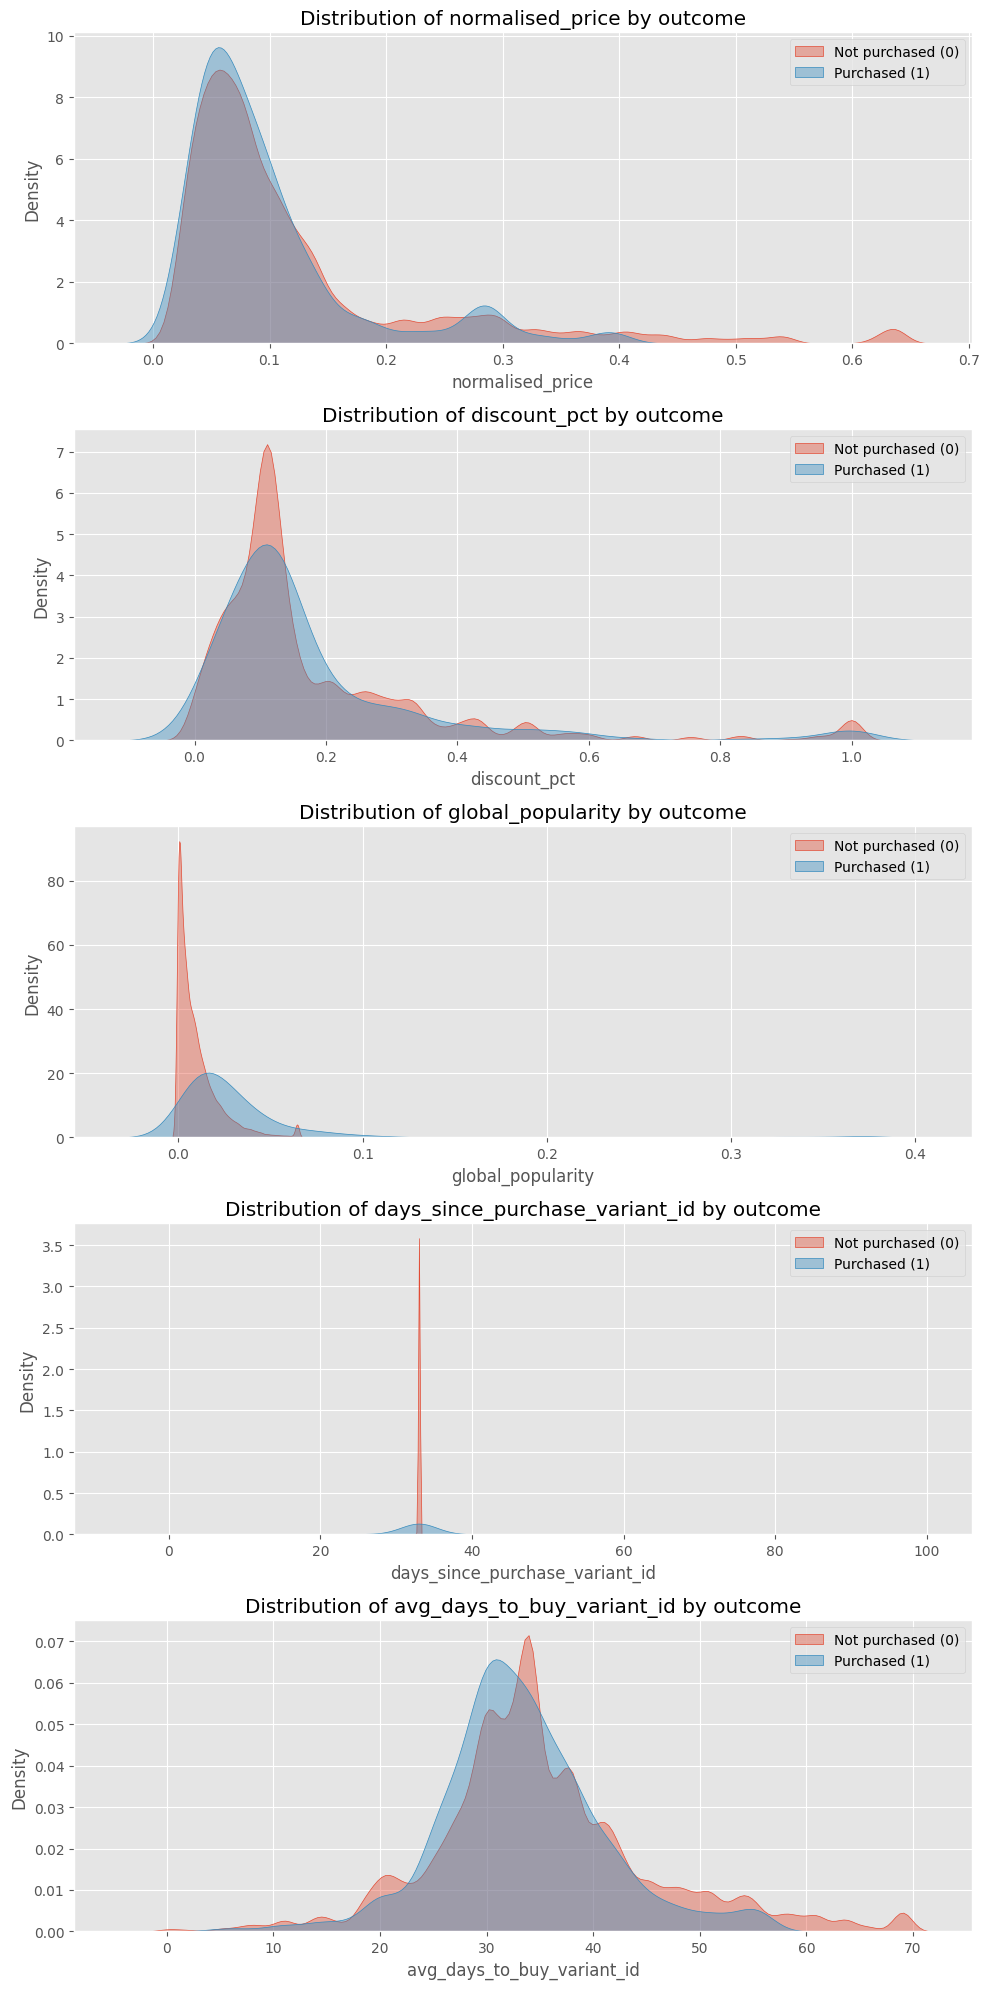

In [39]:
# Sample for performance (full dataset has ~2.9M rows)
sample = feature_frame.sample(n=min(200_000, len(feature_frame)), random_state=42)

fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 4 * len(num_cols)))

palette = {0.0: 'C0', 1.0: 'C1'}
labels  = {0.0: 'Not purchased (0)', 1.0: 'Purchased (1)'}

for ax, col in zip(axes, num_cols):
    for outcome_val in [0.0, 1.0]:
        subset = sample[sample['outcome'] == outcome_val][col].dropna()
        # Clip extreme outliers for visual clarity
        clip_high = subset.quantile(0.99)
        sns.kdeplot(
            subset.clip(upper=clip_high),
            ax=ax, fill=True, alpha=0.4,
            color=palette[outcome_val], label=labels[outcome_val]
        )
    ax.set_title(f'Distribution of {col} by outcome')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

**Insights – Numerical feature distributions:**

- `normalised_price`: Both distributions are very similar and heavily overlap, with peaks around 0.08. 
  The purchased group (1) shows a slightly heavier tail towards mid-range prices (~0.3), but the 
  separation is weak. Price alone is not a strong discriminator, consistent with the bucketed 
  bar chart results.

- `discount_pct`: Near-identical distributions for both classes, with a sharp peak near 0.1 and 
  heavy overlap throughout. This confirms that discount is not a meaningful driver of purchase 
  decisions on its own.

- `global_popularity`: The non-purchased class (0) is extremely concentrated near zero, while the 
  purchased class (1) is much more spread to the right. This is the clearest visual separation 
  among all features, confirming `global_popularity` as the strongest numerical signal.

- `days_since_purchase_variant_id`: The non-purchased class shows the expected spike at 33 
  (the no-history placeholder), which completely dominates the distribution. The purchased class 
  is much flatter and more evenly spread across real elapsed-day values. This confirms the 
  feature needs engineering before modelling — a binary flag `has_purchase_history` 
  (i.e. `days != 33`) would likely capture most of the signal cleanly.

- `avg_days_to_buy_variant_id`: Both distributions are centred around 30–35 days (roughly monthly 
  repurchase cycles) and overlap strongly. However, the purchased class is slightly more peaked 
  and shifted rightward (~35 days), suggesting that products with a more predictable, regular 
  repurchase cadence are marginally more likely to be bought. The separation is modest.

### 6.6 Bucketed purchase rate by numerical feature

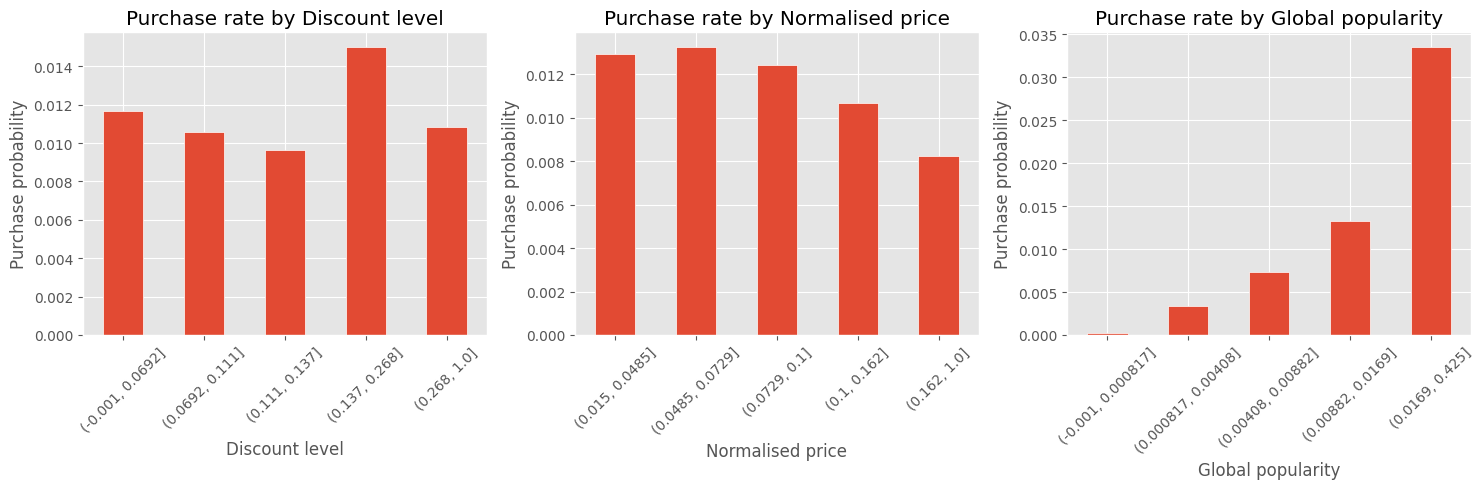

In [40]:
bucket_cols = {
    'discount_pct':     'Discount level',
    'normalised_price': 'Normalised price',
    'global_popularity': 'Global popularity',
}

fig, axes = plt.subplots(1, len(bucket_cols), figsize=(15, 5))

for ax, (col, label) in zip(axes, bucket_cols.items()):
    bucket_col = f'_bucket_{col}'
    feature_frame[bucket_col] = pd.qcut(feature_frame[col], 5, duplicates='drop')
    purchase_rate = feature_frame.groupby(bucket_col, observed=True)['outcome'].mean()
    purchase_rate.plot(kind='bar', ax=ax, color='C0', edgecolor='white')
    ax.set_title(f'Purchase rate by {label}')
    ax.set_ylabel('Purchase probability')
    ax.set_xlabel(label)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights – Purchase rate by numerical feature (bucketed):**

- `discount_pct`: No clear monotonic trend — purchase probability fluctuates between ~1% and 
  ~1.5% across buckets with no consistent direction. The fourth bucket (0.137–0.268) shows a 
  slight peak but the last bucket (>0.268) drops back down. This confirms what the KDE plot 
  suggested: **discount is not a meaningful driver** of purchase decisions.

- `normalised_price`: A clearer negative trend — purchase probability is highest in the two 
  cheapest buckets (~1.3%) and declines steadily as price increases, dropping to ~0.8% for the 
  most expensive bucket. The effect is **consistent and directional**, making price a more 
  reliable signal than discount. As a reminder, this is a relative scale normalised to the most 
  expensive product in the catalogue, not an absolute price.

- `global_popularity`: By far the most striking pattern — purchase probability is near zero for 
  the least popular products and jumps to **~3.4% for the top popularity bucket**, a roughly 
  **30× lift** over the bottom bucket. The relationship is strongly monotonic and the scale of 
  the effect dwarfs both price and discount. This is the **strongest numerical feature** in the 
  dataset and should be prioritised in any predictive model.